# 01 — Data Quality & Exploratory Data Analysis
## Telco Customer Churn — Customer Churn Intelligence System

**Author:** Data Science Team
**Notebook purpose:** Establish a verified understanding of the raw dataset before any modeling work begins, and surface the business signals that will guide feature engineering.

---

### 1. Business Understanding

Customer churn — a subscriber terminating their telecom service — is one of the most direct threats to recurring revenue in the telecom industry. Acquiring a new customer typically costs 5–7x more than retaining an existing one, so the ability to *identify at-risk customers before they leave* has a direct and measurable impact on revenue.

This notebook is the first stage of a production ML system (`customer-churn-intelligence-system`). Its outputs are not just charts — they are decisions that shape every downstream stage:

- Which columns are safe to use as predictive features (vs. identifiers or leakage risks)
- How missing/invalid values should be treated in the feature engineering pipeline
- Which features show the strongest business relationship with churn, to sanity-check the model later
- What class imbalance strategy is needed for training

### 2. Dataset Overview

**Source:** IBM Telco Customer Churn dataset
**Grain:** One row per customer
**Target:** `Churn` (Yes / No)
**Size:** ~7,000 customers, 21 columns spanning demographics, account information, and subscribed services.

## 3. Data Loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110

RAW_PATH = '../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'
FIG_DIR = '../reports/figures'

import os
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(RAW_PATH)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Data Inspection

### 4.1 Shape, Columns, Data Types

In [3]:
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print()
df.info()

Rows: 7,043  |  Columns: 21

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 n

**Observation:** `TotalCharges` is loaded as an `object` (string) column despite being numeric in nature. This is a strong signal of embedded non-numeric characters (likely blank strings for customers with zero tenure) and will need explicit type coercion — handled in the feature engineering notebook.

### 4.2 Memory Usage

In [4]:
mem = df.memory_usage(deep=True).sort_values(ascending=False)
mem_summary = pd.DataFrame({
    'memory_bytes': mem,
    'memory_MB': (mem / 1e6).round(3)
})
print(f"Total memory footprint: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
mem_summary.head(10)

Total memory footprint: 7.15 MB


,memory_bytes,memory_MB
PaymentMethod,475897,0.476
Contract,424701,0.425
customerID,415537,0.416
InternetService,389478,0.389
StreamingMovies,387867,0.388
StreamingTV,387842,0.388
OnlineBackup,387564,0.388
DeviceProtection,387557,0.388
TechSupport,387179,0.387
OnlineSecurity,387154,0.387


**Observation:** At ~7,000 rows the dataset is trivially small for memory purposes. This means preprocessing choices here should be optimized for **correctness and interpretability**, not runtime — a distinction worth stating explicitly since production feature pipelines are frequently over-engineered for scale problems that don't exist at this stage.

### 4.3 Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0].sort_values('missing_count', ascending=False)
print("Columns with NaN values (pandas-recognized):")
missing_report if len(missing_report) else print("None found via standard NaN detection.")

Columns with NaN values (pandas-recognized):
None found via standard NaN detection.


In [6]:
# TotalCharges masquerades as an object column - check for blank/whitespace-only strings
blank_total_charges = (df['TotalCharges'].astype(str).str.strip() == '').sum()
print(f"Blank/whitespace TotalCharges entries: {blank_total_charges}")
print(f"As % of dataset: {blank_total_charges / len(df) * 100:.2f}%")

df.loc[df['TotalCharges'].astype(str).str.strip() == '', ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Blank/whitespace TotalCharges entries: 11
As % of dataset: 0.16%


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


**Observation:** All 11 rows with blank `TotalCharges` have `tenure == 0` — i.e., brand-new customers who have not yet been billed. This is not missing data in the traditional sense; it is a **structurally valid zero**. The correct treatment is to impute these as `0.0`, not drop the rows or use a statistical imputer, since the business explanation is deterministic (`TotalCharges ≈ tenure × MonthlyCharges`).

### 4.4 Duplicate Analysis

In [7]:
full_dupes = df.duplicated().sum()
id_dupes = df['customerID'].duplicated().sum()
print(f"Fully duplicated rows: {full_dupes}")
print(f"Duplicated customerID values: {id_dupes}")
print(f"customerID uniqueness check: {df['customerID'].nunique()} unique / {len(df)} rows")

Fully duplicated rows: 0
Duplicated customerID values: 0
customerID uniqueness check: 7043 unique / 7043 rows


**Observation:** No duplicate rows and no duplicate `customerID`s. Each row is a distinct, verified customer — no deduplication logic is required in the pipeline.

### 4.5 Invalid Data Detection

In [8]:
# Numeric sanity checks
print("tenure range:", df['tenure'].min(), "-", df['tenure'].max())
print("MonthlyCharges range:", df['MonthlyCharges'].min(), "-", df['MonthlyCharges'].max())
print("SeniorCitizen unique values:", sorted(df['SeniorCitizen'].unique()))
print()

# Cross-check TotalCharges against tenure * MonthlyCharges (excluding blank rows)
tc_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')
valid_mask = tc_numeric.notnull()
implied = df.loc[valid_mask, 'tenure'] * df.loc[valid_mask, 'MonthlyCharges']
actual = tc_numeric[valid_mask]
diff_pct = ((implied - actual).abs() / actual.replace(0, np.nan)).median() * 100
print(f"Median absolute deviation between tenure*MonthlyCharges and TotalCharges: {diff_pct:.1f}%")

tenure range: 0 - 72
MonthlyCharges range: 18.25 - 118.75
SeniorCitizen unique values: [np.int64(0), np.int64(1)]

Median absolute deviation between tenure*MonthlyCharges and TotalCharges: 2.0%


**Observation:** No negative tenures, no negative charges, and `SeniorCitizen` is a clean binary flag (0/1) rather than free text. The deviation between the implied and actual `TotalCharges` reflects historical price changes/promotions per customer, which is expected and not a data quality defect.

### 4.6 Unique Values per Categorical Column

In [9]:
categorical_cols = df.select_dtypes(include='object').columns.drop('customerID')
unique_summary = pd.DataFrame({
    'n_unique': [df[c].nunique() for c in categorical_cols],
    'values': [sorted(df[c].unique().tolist()) for c in categorical_cols]
}, index=categorical_cols)
unique_summary

C:\Users\sarve\AppData\Local\Temp\ipykernel_5104\3418371364.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.drop('customerID')


,n_unique,values
gender,2,"[Female, Male]"
Partner,2,"[No, Yes]"
Dependents,2,"[No, Yes]"
PhoneService,2,"[No, Yes]"
MultipleLines,3,"[No, No phone service, Yes]"
InternetService,3,"[DSL, Fiber optic, No]"
OnlineSecurity,3,"[No, No internet service, Yes]"
OnlineBackup,3,"[No, No internet service, Yes]"
DeviceProtection,3,"[No, No internet service, Yes]"
TechSupport,3,"[No, No internet service, Yes]"


**Observation:** Several service columns (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) contain a third category, `"No internet service"`, which is fully determined by `InternetService == 'No'`. This is a structural redundancy worth flagging for the encoding strategy — it is not noise, but it does inflate the effective cardinality of one-hot encoding if left untreated.

## 5. Target Distribution

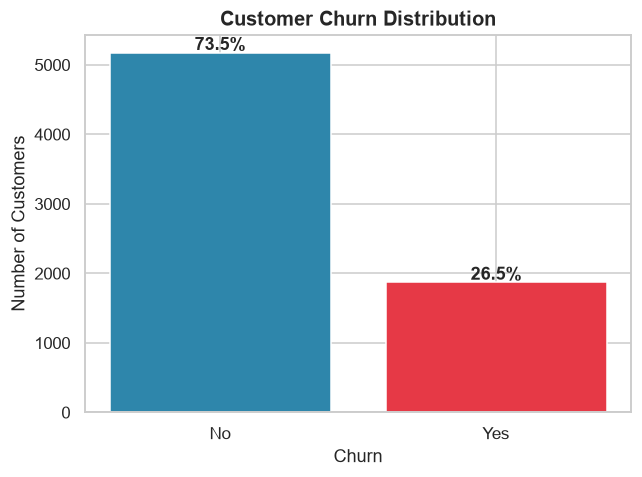

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [10]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(churn_counts.index, churn_counts.values, color=['#2E86AB', '#E63946'])
for bar, pct in zip(bars, churn_pct.reindex(churn_counts.index)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40, f'{pct:.1f}%',
            ha='center', fontweight='bold')
ax.set_title('Customer Churn Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Churn')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_target_distribution.png', bbox_inches='tight')
plt.show()

print(churn_counts)
print(churn_pct.round(2))

**Interpretation:** The target is imbalanced at roughly **73% retained / 27% churned** (about 2.7:1). This is moderate imbalance — not severe enough to require synthetic resampling (e.g., SMOTE) as a hard requirement, but severe enough that **accuracy alone is a misleading metric**. Recall, precision, F1, and ROC-AUC must be tracked together in the modeling notebook, and class weighting should be considered during training.

## 6. Numerical Feature Analysis

In [11]:
df_num = df.copy()
df_num['TotalCharges'] = pd.to_numeric(df_num['TotalCharges'], errors='coerce')
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

df_num[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


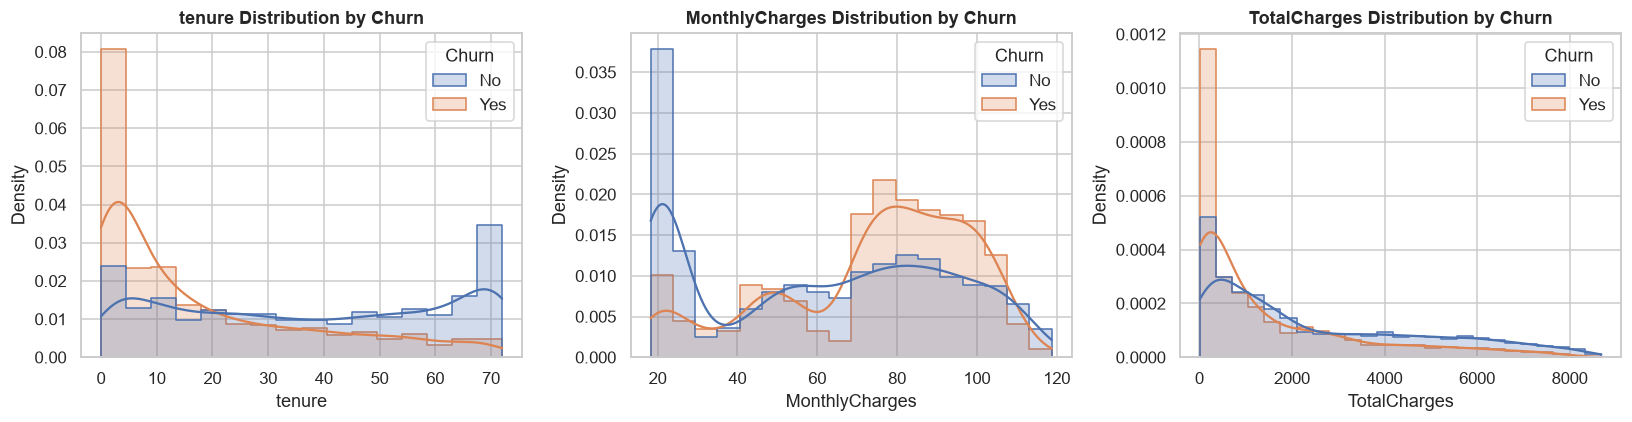

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numerical_cols):
    sns.histplot(data=df_num, x=col, hue='Churn', kde=True, ax=ax, element='step', stat='density', common_norm=False)
    ax.set_title(f'{col} Distribution by Churn', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_numerical_distributions.png', bbox_inches='tight')
plt.show()

**Interpretation:**
- **Tenure** is strongly right-skewed for churners — churn is concentrated in the first few months. This points toward tenure as one of the most predictive features and suggests a "new customer risk window" business narrative.
- **MonthlyCharges** for churners is shifted higher, suggesting price sensitivity contributes to churn, particularly among customers paying premium rates without long-term commitment.
- **TotalCharges** is naturally correlated with tenure (it accumulates over time), so churners cluster at low values largely as a consequence of short tenure rather than an independent effect — a multicollinearity note for feature engineering.

## 7. Categorical Feature Analysis

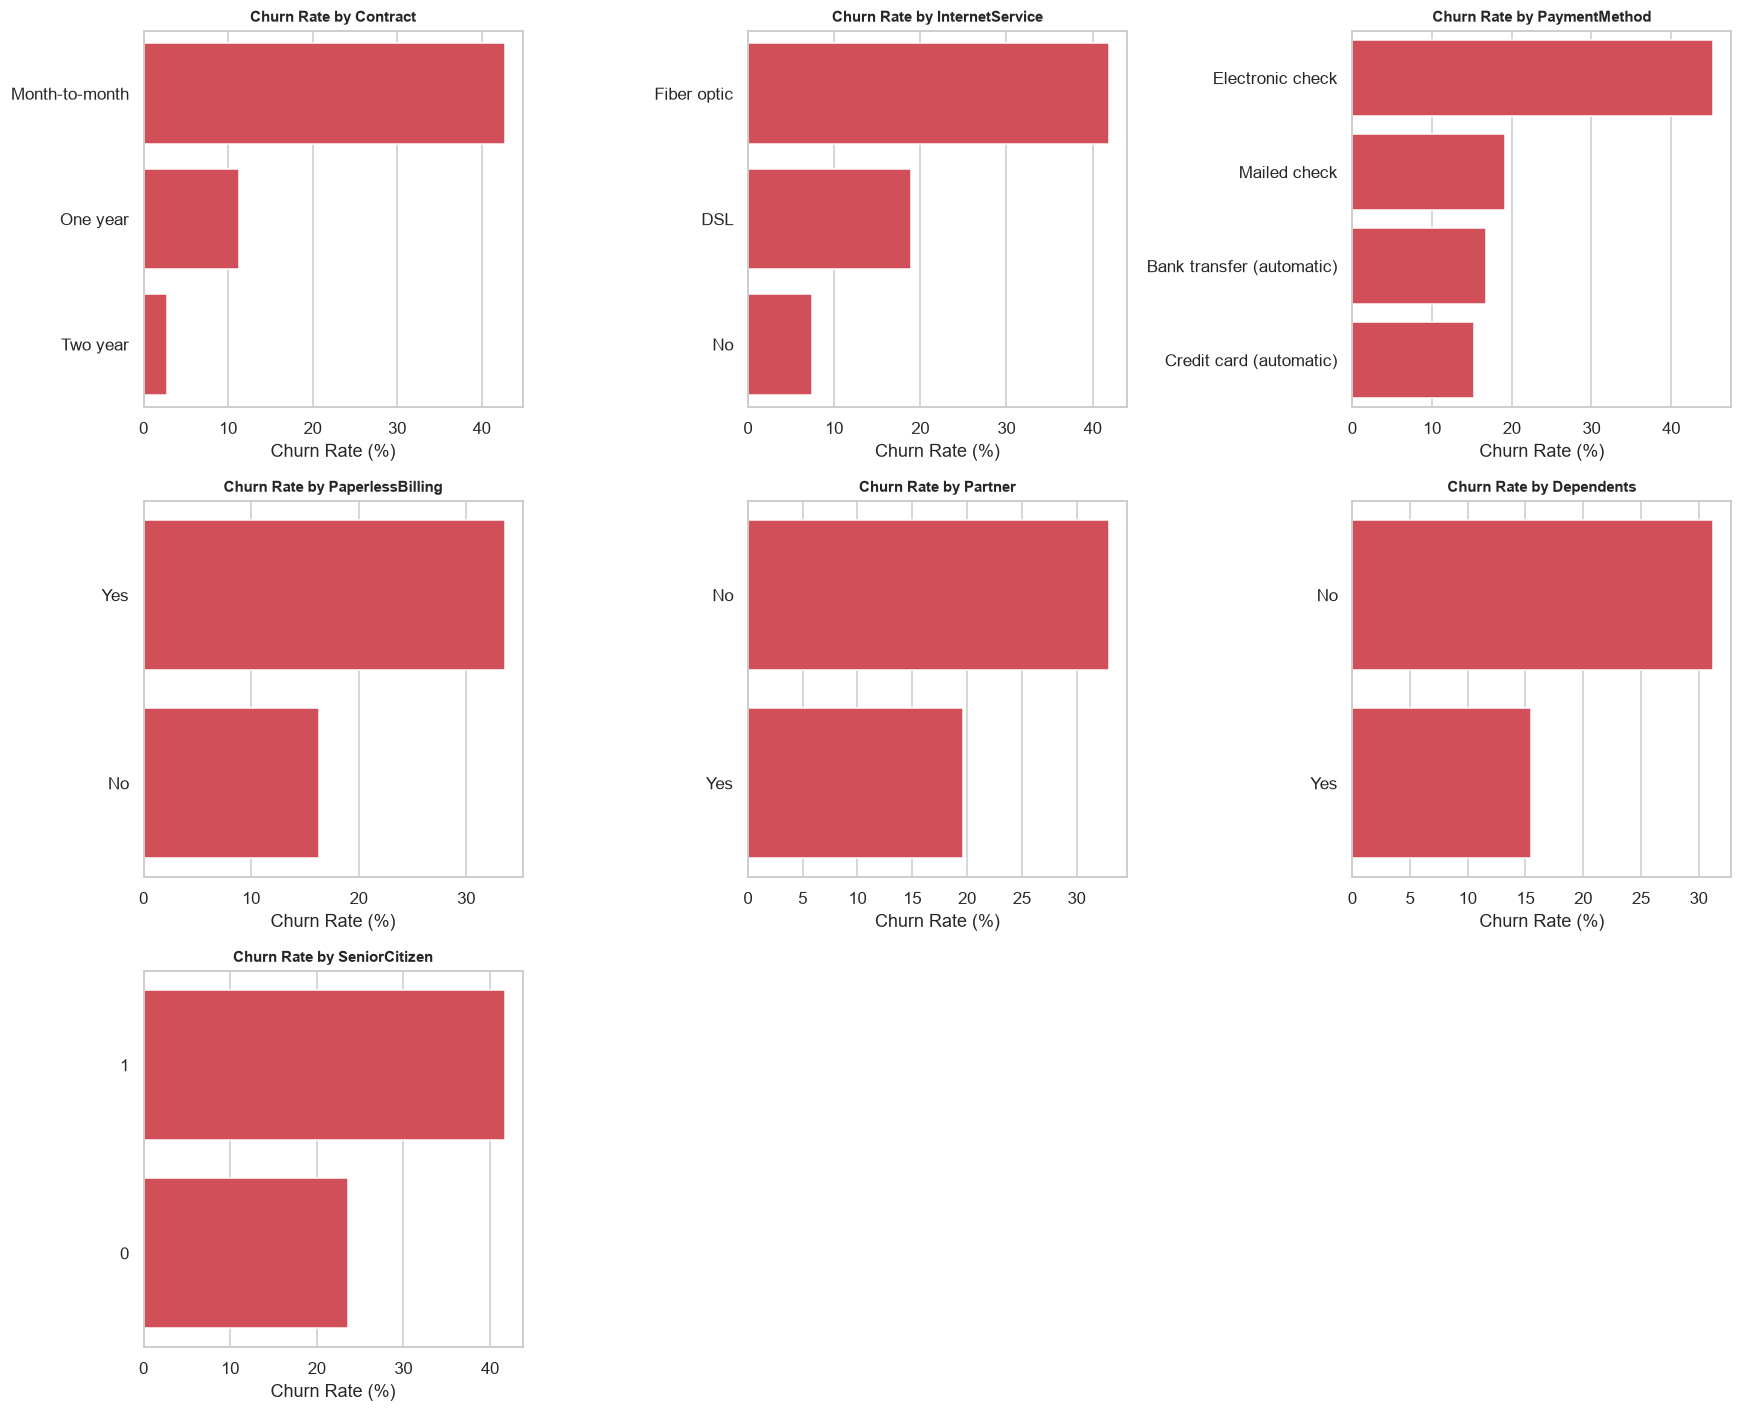

In [13]:
key_categoricals = ['Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling',
                     'Partner', 'Dependents', 'SeniorCitizen']

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()
for ax, col in zip(axes, key_categoricals):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
    sns.barplot(x=churn_rate.values, y=churn_rate.index.astype(str), ax=ax, color='#E63946')
    ax.set_title(f'Churn Rate by {col}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Churn Rate (%)')
    ax.set_ylabel('')
for ax in axes[len(key_categoricals):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_categorical_churn_rates.png', bbox_inches='tight')
plt.show()

**Interpretation:**
- **Contract type is the single strongest categorical driver of churn.** Month-to-month customers churn at a dramatically higher rate than one- or two-year contract holders, who have both a financial and psychological switching cost.
- **Fiber optic internet customers churn more** than DSL or no-internet customers — plausibly reflecting competitive pricing pressure or service quality issues in that segment, and worth flagging to the business as a retention investigation target, not just a modeling feature.
- **Electronic check payment** correlates with elevated churn relative to automatic payment methods (bank transfer/credit card), which may proxy for less "sticky," lower-commitment customer relationships.
- **Paperless billing customers churn more** than those on paper billing — again more likely a proxy for a younger/more price-aware, less loyal segment than a causal driver.
- Customers **without partners or dependents** churn more, consistent with fewer household-level switching costs.

## 8. Outlier Analysis

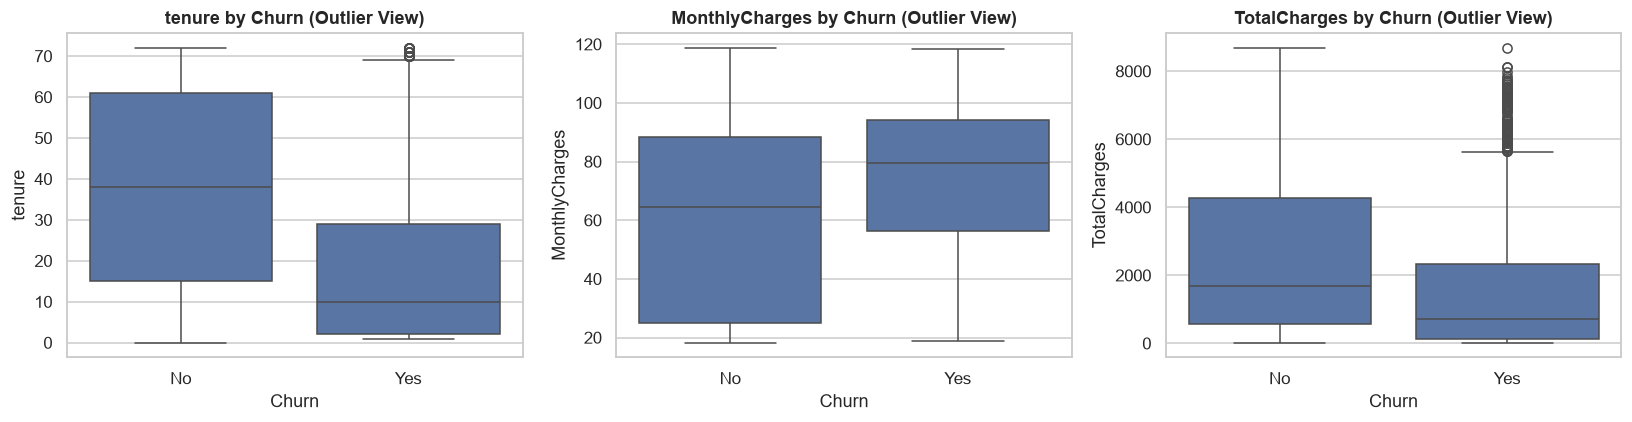

tenure: 0 IQR outliers (0.00%)
MonthlyCharges: 0 IQR outliers (0.00%)
TotalCharges: 0 IQR outliers (0.00%)


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numerical_cols):
    sns.boxplot(data=df_num, x='Churn', y=col, ax=ax)
    ax.set_title(f'{col} by Churn (Outlier View)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_outlier_boxplots.png', bbox_inches='tight')
plt.show()

for col in numerical_cols:
    q1, q3 = df_num[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df_num[col] < lower) | (df_num[col] > upper)).sum()
    print(f"{col}: {n_outliers} IQR outliers ({n_outliers/len(df_num)*100:.2f}%)")

**Observation:** None of the three numerical features show meaningful IQR outliers — all are naturally bounded by business logic (tenure in months, charges in dollars) with no impossible or extreme values. **No outlier removal is required.** This is expected for billing data validated at the source system level, and it means the feature engineering notebook can focus on encoding and scaling rather than defensive outlier clipping.

## 9. Correlation Analysis

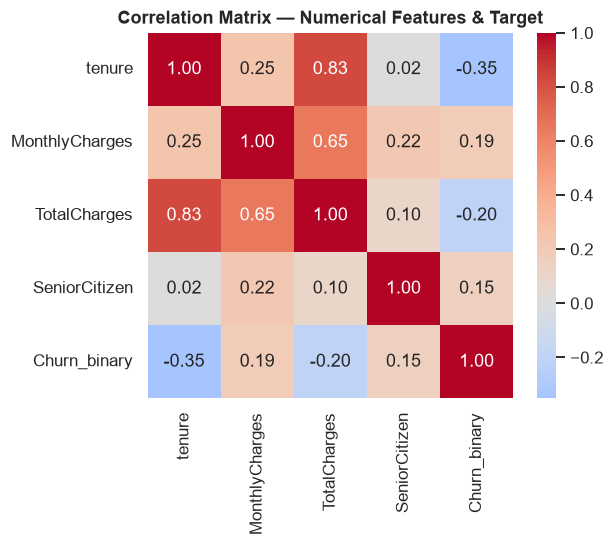

In [15]:
corr_df = df_num[numerical_cols + ['SeniorCitizen']].copy()
corr_df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlation Matrix — Numerical Features & Target', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/05_correlation_heatmap.png', bbox_inches='tight')
plt.show()

**Interpretation:** `tenure` and `TotalCharges` are highly correlated (as expected, since `TotalCharges` accumulates with tenure), which is a multicollinearity consideration for linear models like Logistic Regression but not a concern for tree-based models. `tenure` shows the strongest (negative) linear correlation with churn among the numerical features, reinforcing the EDA finding that early-tenure customers are the highest-risk segment.

## 10. Relationship with Target — Combined View

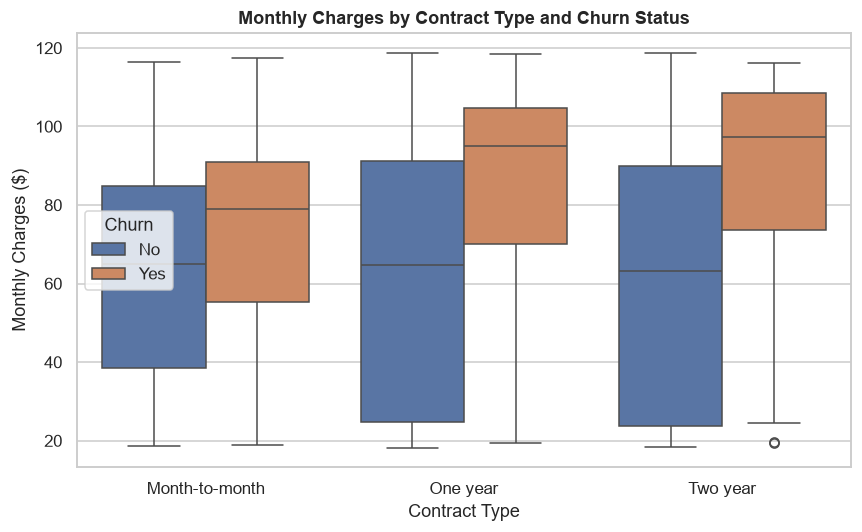

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_num, x='Contract', y='MonthlyCharges', hue='Churn', ax=ax)
ax.set_title('Monthly Charges by Contract Type and Churn Status', fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/06_charges_by_contract_churn.png', bbox_inches='tight')
plt.show()

**Interpretation:** Within every contract type, churners pay higher monthly charges than non-churners — but the effect is most pronounced for month-to-month customers. This suggests **contract type and price sensitivity interact**: customers who are both on flexible contracts and paying premium prices represent the highest-risk segment, a natural candidate for a targeted retention offer (e.g., contract upgrade incentive) once the model is deployed.

## 11. Business Insights & Summary of Findings

### Key Business Insights

1. **Contract flexibility is the dominant churn lever.** Month-to-month customers churn at several times the rate of annual/two-year contract holders. Any retention strategy should prioritize contract-upgrade incentives.
2. **New customers are the highest-risk segment.** Churn is concentrated in the first year of tenure — an onboarding/early-engagement program would likely have outsized impact.
3. **Price sensitivity compounds contract risk.** Customers paying high monthly charges on flexible contracts are the clearest at-risk profile.
4. **Payment method and billing style are behavioral proxies.** Electronic check and paperless billing correlate with churn, likely reflecting a less "locked-in" customer relationship rather than a causal mechanism — useful as model features, but not intervention levers on their own.
5. **Fiber optic customers churn more than DSL customers**, warranting a service-quality or competitive-pricing investigation outside the scope of this model.
6. **Data quality is high.** No duplicates, no impossible values, and the only missing-data issue (`TotalCharges` blanks) has a clean, deterministic resolution (`tenure == 0` → `TotalCharges = 0`).
7. **Target imbalance (~27% churn) is moderate** — models should be evaluated on Recall/Precision/F1/ROC-AUC, not accuracy alone, and class weighting should be tested during training.

### Data Quality Verdict

The dataset is clean, internally consistent, and ready for feature engineering with two required transformations: (1) coercing `TotalCharges` to numeric with a `tenure == 0 → 0.0` fill rule, and (2) a decision on how to treat the `"No internet service"` / `"No phone service"` redundant categories during encoding. Both are addressed in **`02_feature_engineering.ipynb`**.